# Exploratory Data Analysis — mAb Bioprocess Titer Prediction

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 100

DATA_DIR = Path("../interview_files")

train_data = pd.read_csv(DATA_DIR / "datahow_interview_train_data.csv")
train_targets = pd.read_csv(DATA_DIR / "datahow_interview_train_targets.csv")
test_data = pd.read_csv(DATA_DIR / "datahow_interview_test_data.csv")
test_template = pd.read_csv(DATA_DIR / "datahow_interview_test_targets-TEMPLATE.csv")

print(f"Train data:    {train_data.shape}")
print(f"Train targets: {train_targets.shape}")
print(f"Test data:     {test_data.shape}")
print(f"Test template: {test_template.shape}")
print(f"\nTrain experiments: {train_data['Exp'].nunique()}")
print(f"Test experiments:  {test_data['Exp'].nunique()}")

# Column groups
z_cols = [c for c in train_data.columns if c.startswith('Z:')]
w_cols = [c for c in train_data.columns if c.startswith('W:')]
x_cols = [c for c in train_data.columns if c.startswith('X:')]
print(f"\nZ: {len(z_cols)} scalar params, W: {len(w_cols)} time-series inputs, X: {len(x_cols)} observations")

Train data:    (990, 26)
Train targets: (100, 4)
Test data:     (300, 26)
Test template: (20, 4)

Train experiments: 100
Test experiments:  20

Z: 13 scalar params, W: 4 time-series inputs, X: 6 observations


**Data overview.** 100 training experiments, 20 test experiments. Each row is one experiment-day (990 training rows = 100 experiments × ~10 avg days). Three variable groups: Z: (13 scalar DoE parameters, constant per experiment), W: (4 time-series inputs), X: (6 time-series observations). Target: Y:Titer, one scalar per experiment.

In [2]:
# How is the data structured? One row per experiment per day.
# Let's understand how experiment duration, data length, and target day relate.

exp_info = train_data[train_data["Time[day]"] == 0][["Exp", "Z:ExpDuration"]].copy()
exp_info = exp_info.merge(train_targets[["Exp", "Time[day]", "Y:Titer"]], on="Exp")

# Compute actual data stats per experiment
data_stats = train_data.groupby("Exp").agg(
    n_timesteps=("Time[day]", "size"),
    max_day=("Time[day]", "max"),
    min_day=("Time[day]", "min")
).reset_index()
exp_info = exp_info.merge(data_stats, on="Exp")

print("=== Per-experiment summary (first 15) ===")
print(exp_info[["Exp", "Z:ExpDuration", "Time[day]", "n_timesteps", "max_day"]].head(15).to_string(index=False))

print()
print("=== Key relationships ===")
match_target = (exp_info["Z:ExpDuration"] == exp_info["Time[day]"]).all()
match_maxday = (exp_info["Z:ExpDuration"] == exp_info["max_day"]).all()
match_nsteps = (exp_info["n_timesteps"] == exp_info["Z:ExpDuration"] + 1).all()
match_start = (exp_info["min_day"] == 0).all()
print(f"Z:ExpDuration == Target Time[day]:  {match_target}")
print(f"Z:ExpDuration == max day of data:   {match_maxday}")
print(f"n_timesteps == ExpDuration + 1:     {match_nsteps}")
print(f"All start at day 0:                 {match_start}")

print()
print("=== Duration distribution ===")
print(exp_info["Z:ExpDuration"].value_counts().sort_index().to_string())


=== Per-experiment summary (first 15) ===
   Exp  Z:ExpDuration  Time[day]  n_timesteps  max_day
 Exp 1           10.0         10           11       10
 Exp 2           10.0         10           11       10
 Exp 3            9.0          9           10        9
 Exp 4            9.0          9           10        9
 Exp 5            8.0          8            9        8
 Exp 6            8.0          8            9        8
 Exp 7            7.0          7            8        7
 Exp 8            7.0          7            8        7
 Exp 9            7.0          7            8        7
Exp 10           14.0         14           15       14
Exp 11           10.0         10           11       10
Exp 12           14.0         14           15       14
Exp 13            9.0          9           10        9
Exp 14            9.0          9           10        9
Exp 15            8.0          8            9        8

=== Key relationships ===
Z:ExpDuration == Target Time[day]:  True
Z:ExpDurat

**How does experiment duration relate to data structure and the target?** All structural invariants hold: ExpDuration = target day = max data day, n_timesteps = duration + 1, all start at day 0. Duration distribution is unbalanced: 30 experiments at 7d but only 10 at 14d — and the test set is entirely 14d. This 10% overlap will constrain our validation strategy.

In [3]:
# Are W: variables fully determined by Z: scalar params?
# Hypothesis: step functions from Z: scalars should reconstruct W: exactly.

w_rules = {
    "W:temp":    ("Z:tempStart",   "Z:tempEnd",   "Z:tempShift",  "shift"),
    "W:pH":      ("Z:phStart",     "Z:phEnd",     "Z:phShift",    "shift"),
    "W:FeedGlc": ("Z:FeedRateGlc", None,          None,           "feed"),
    "W:FeedGln": ("Z:FeedRateGln", None,          None,           "feed"),
}

z_rows = train_data[train_data["Time[day]"] == 0].set_index("Exp")
max_errors = {w: 0.0 for w in w_rules}

for exp_name in exp_info["Exp"]:
    ed = train_data[train_data["Exp"] == exp_name]
    z = z_rows.loc[exp_name]
    t = ed["Time[day]"].values
    for w_col, (p1, p2, p3, mode) in w_rules.items():
        if mode == "shift":
            expected = np.where(t < z[p3], z[p1], z[p2])
        else:  # feed: active between FeedStart and FeedEnd
            expected = np.where((t >= z["Z:FeedStart"]) & (t < z["Z:FeedEnd"]), z[p1], 0.0)
        max_errors[w_col] = max(max_errors[w_col], np.max(np.abs(ed[w_col].values - expected)))

print("Max reconstruction error per W: variable (across all 100 experiments):")
for w_col, err in max_errors.items():
    status = "match exactly" if err < 1e-10 else f"max error = {err:.2e}"
    print(f"  {w_col:12s}  max_error = {err:.2e}  (100/100 experiments {status})")

if max(max_errors.values()) < 1e-10:
    print("\n=> W: is FULLY deterministic from Z:. No independent information.")

Max reconstruction error per W: variable (across all 100 experiments):
  W:temp        max_error = 0.00e+00  (100/100 experiments match exactly)
  W:pH          max_error = 0.00e+00  (100/100 experiments match exactly)
  W:FeedGlc     max_error = 0.00e+00  (100/100 experiments match exactly)
  W:FeedGln     max_error = 0.00e+00  (100/100 experiments match exactly)

=> W: is FULLY deterministic from Z:. No independent information.


**Are W: variables independent inputs or derived from Z: scalars?** The 4 W: time-series (temp, pH, FeedGlc, FeedGln) reconstruct perfectly from Z: setpoints using step functions — zero error across all 100 experiments. W: carries no independent predictor information beyond Z:, but remains useful for computing derived features like cumulative feed via time integration.

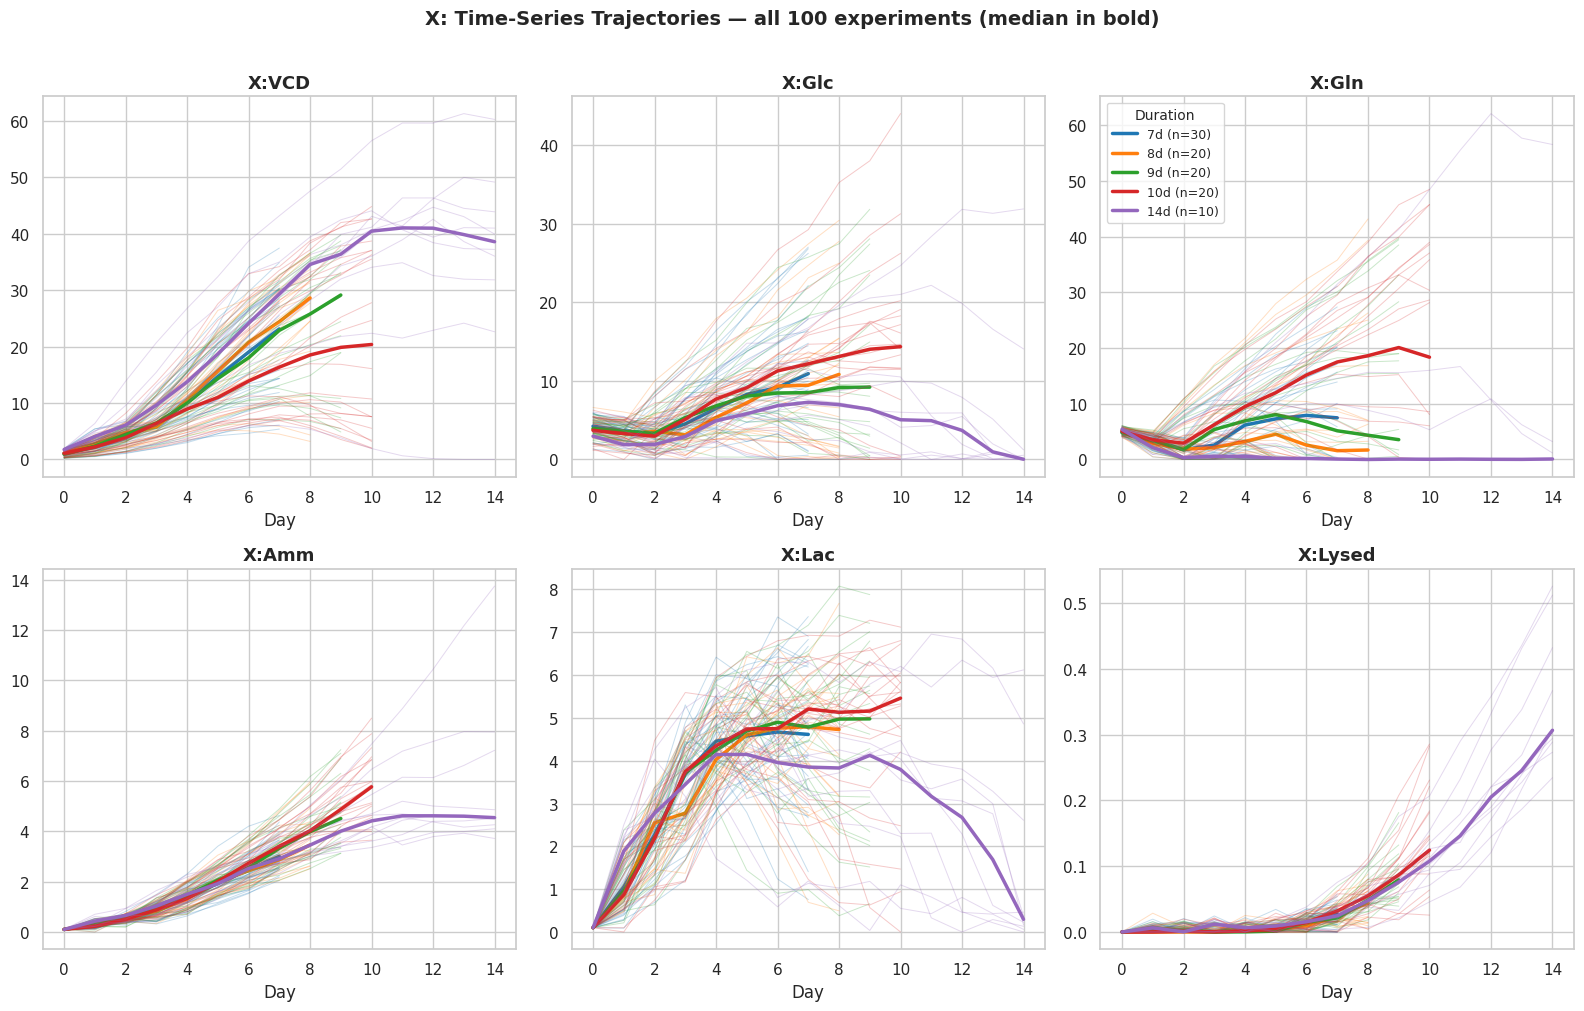

In [4]:
# X: time-series trajectories — do they match literature expectations?
# Hutter (2021, same simulator): VCD=logistic growth→peak→decline, Glc/Gln=sawtooth depletion+feed jumps,
# Amm=monotonic increase, Lac=TWO CLUSTERS (consumers vs producers), Titer=monotonic increase.

# Plot ALL 100 experiments (alpha=0.3) with bold median per duration group.
durations = sorted(exp_info["Z:ExpDuration"].unique())
dur_colors = {7.0: "#1f77b4", 8.0: "#ff7f0e", 9.0: "#2ca02c", 10.0: "#d62728", 14.0: "#9467bd"}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, xcol in zip(axes.flat, x_cols):
    for dur in durations:
        dur_exps = exp_info[exp_info["Z:ExpDuration"] == dur]["Exp"].values
        # Collect trajectories for median
        trajectories = []
        for exp_name in dur_exps:
            edata = train_data[train_data["Exp"] == exp_name].sort_values("Time[day]")
            t = edata["Time[day]"].values
            y = edata[xcol].values
            ax.plot(t, y, color=dur_colors[dur], alpha=0.25, lw=0.7)
            trajectories.append(y)
        # Bold median line (all experiments in a duration group have the same length)
        median_y = np.median(trajectories, axis=0)
        median_t = np.arange(len(median_y))
        ax.plot(median_t, median_y, color=dur_colors[dur], lw=2.5, label=f"{int(dur)}d (n={len(dur_exps)})")
    ax.set_title(xcol, fontsize=13, fontweight="bold")
    ax.set_xlabel("Day")

# Shared legend
axes[0, 2].legend(fontsize=9, title="Duration", title_fontsize=10)
fig.suptitle("X: Time-Series Trajectories — all 100 experiments (median in bold)", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

**Do time-series trajectories match bioprocess literature?** Yes — VCD follows logistic growth → peak → decline (Hutter 2021, same simulator); Glc/Gln show depletion + feed refill; Amm increases monotonically. Two patterns to investigate: (1) Gln shows a striking bimodal split — some experiments deplete to zero, others accumulate to 30+, and (2) Lac reveals two metabolic phenotypes (consumers vs. sustained producers). Shorter experiments truncate before late-phase dynamics emerge.

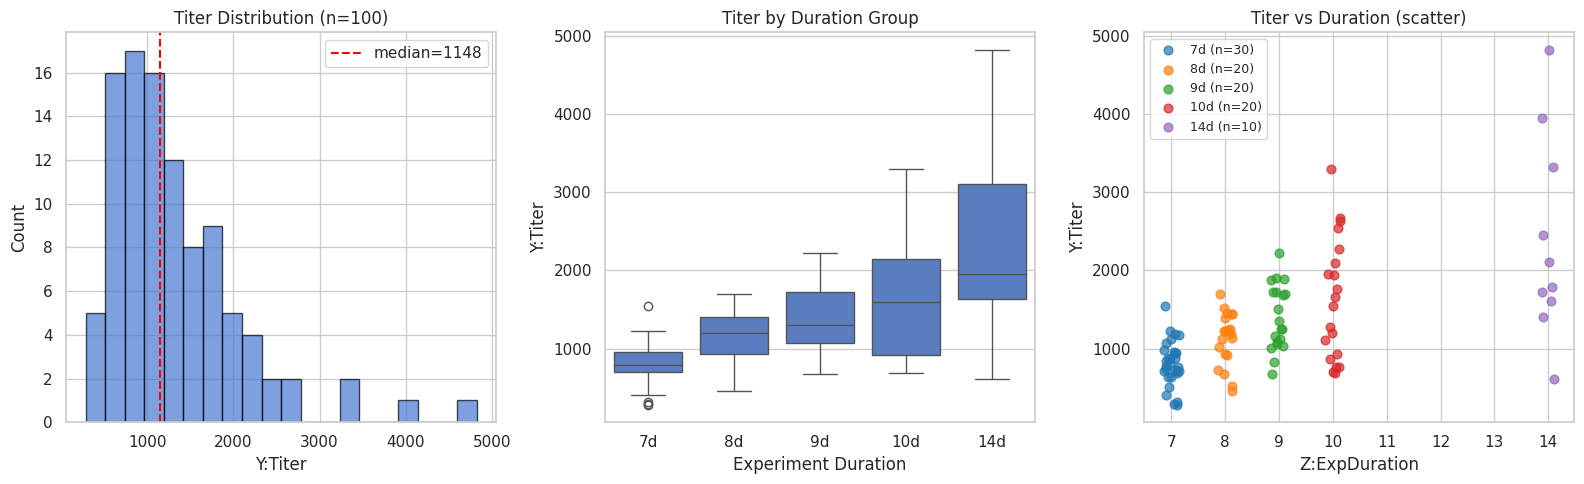

=== Titer summary by duration ===
               count         mean          std         min          max
Z:ExpDuration                                                          
7.0             30.0   810.984426   288.690046  283.456126  1547.253264
8.0             20.0  1128.302505   339.117683  459.274664  1696.428953
9.0             20.0  1403.253866   417.923195  678.442609  2224.414977
10.0            20.0  1634.330286   778.001283  689.062123  3296.002855
14.0            10.0  2380.346113  1285.092422  609.903525  4822.697067


In [5]:
# Target: Y:Titer distribution and relationship with experiment duration
# Literature (Bayer 2020): expect nonlinear response surface, not just linear trend

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Titer histogram
axes[0].hist(exp_info["Y:Titer"], bins=20, edgecolor="black", alpha=0.7)
axes[0].set_xlabel("Y:Titer")
axes[0].set_ylabel("Count")
axes[0].set_title("Titer Distribution (n=100)")
axes[0].axvline(exp_info["Y:Titer"].median(), color="red", ls="--", label=f'median={exp_info["Y:Titer"].median():.0f}')
axes[0].legend()

# 2. Titer vs duration (boxplot)
exp_info["dur_label"] = exp_info["Z:ExpDuration"].astype(int).astype(str) + "d"
dur_order = [f"{int(d)}d" for d in sorted(exp_info["Z:ExpDuration"].unique())]
sns.boxplot(data=exp_info, x="dur_label", y="Y:Titer", order=dur_order, ax=axes[1])
axes[1].set_xlabel("Experiment Duration")
axes[1].set_ylabel("Y:Titer")
axes[1].set_title("Titer by Duration Group")

# 3. Titer vs duration (scatter with jitter for detail)
for dur, color in dur_colors.items():
    mask = exp_info["Z:ExpDuration"] == dur
    axes[2].scatter(
        exp_info.loc[mask, "Z:ExpDuration"] + np.random.uniform(-0.15, 0.15, mask.sum()),
        exp_info.loc[mask, "Y:Titer"], color=color, alpha=0.7, s=40, label=f"{int(dur)}d (n={mask.sum()})"
    )
axes[2].set_xlabel("Z:ExpDuration")
axes[2].set_ylabel("Y:Titer")
axes[2].set_title("Titer vs Duration (scatter)")
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

# Summary stats
print("=== Titer summary by duration ===")
print(exp_info.groupby("Z:ExpDuration")["Y:Titer"].describe()[["count", "mean", "std", "min", "max"]].to_string())

**What does the target distribution look like, and how does it relate to duration?** Right-skewed (median=1148, range 283–4823) — suggests log-transform for modeling. Mean titer nearly triples from 7d (811) to 14d (2380), and variance increases sharply (7d std=289, 14d std=1285). Duration alone explains ~R²=0.38 — any feature that correlates with duration will appear predictive even without independent signal. This confound will need to be controlled for.

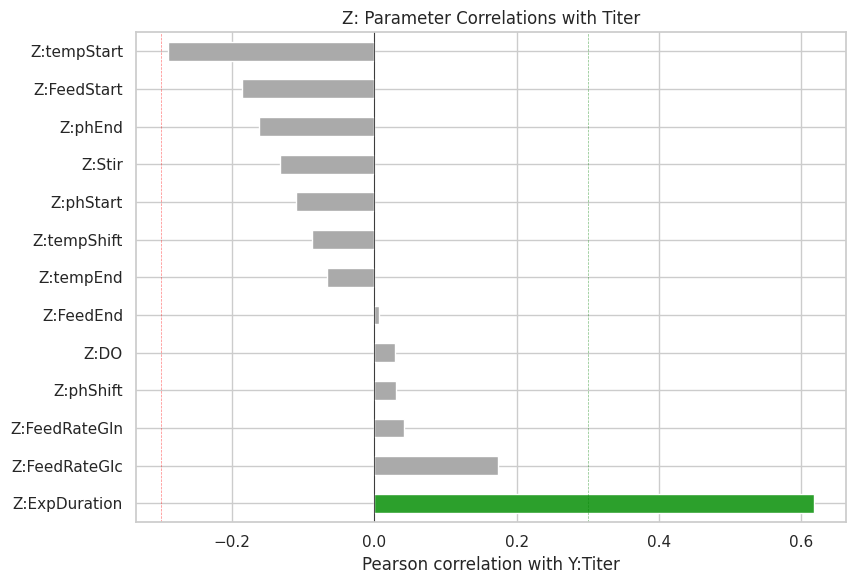

=== Pearson correlation with Y:Titer ===
  Z:ExpDuration         r = +0.618 ***
  Z:FeedRateGlc         r = +0.174 *
  Z:FeedRateGln         r = +0.041
  Z:phShift             r = +0.031
  Z:DO                  r = +0.029
  Z:FeedEnd             r = +0.006
  Z:tempEnd             r = -0.066
  Z:tempShift           r = -0.087
  Z:phStart             r = -0.110
  Z:Stir                r = -0.132
  Z:phEnd               r = -0.162 *
  Z:FeedStart           r = -0.186 *
  Z:tempStart           r = -0.289 *

Top correlated (|r|>0.15): ['Z:ExpDuration', 'Z:FeedRateGlc', 'Z:phEnd', 'Z:FeedStart', 'Z:tempStart']


In [6]:
# Z: scalar params vs Titer — which DoE parameters correlate with titer?
# Build a per-experiment table: Z: params (from t=0 row) + Y:Titer

z_table = train_data[train_data["Time[day]"] == 0][["Exp"] + z_cols].copy()
z_table = z_table.merge(train_targets[["Exp", "Y:Titer"]], on="Exp")

# Correlation matrix of all Z: params with titer
corr_with_titer = z_table[z_cols + ["Y:Titer"]].corr()["Y:Titer"].drop("Y:Titer").sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Bar chart of correlations
colors = ["#2ca02c" if v > 0.3 else "#d62728" if v < -0.3 else "#aaaaaa" for v in corr_with_titer.values]
corr_with_titer.plot.barh(ax=axes[0], color=colors)
axes[0].set_xlabel("Pearson correlation with Y:Titer")
axes[0].set_title("Z: Parameter Correlations with Titer")
axes[0].axvline(0, color="black", lw=0.5)
axes[0].axvline(0.3, color="green", ls="--", lw=0.5, alpha=0.5)
axes[0].axvline(-0.3, color="red", ls="--", lw=0.5, alpha=0.5)

# 2. Scatter matrix of top correlated Z: params (|r| > 0.15) vs titer
top_z = corr_with_titer[corr_with_titer.abs() > 0.15].index.tolist()
n_top = len(top_z)
axes[1].remove()  # remove placeholder, we'll use a new grid

plt.tight_layout()
plt.show()

# Print correlations
print("=== Pearson correlation with Y:Titer ===")
for param, r in corr_with_titer.items():
    flag = " ***" if abs(r) > 0.3 else " *" if abs(r) > 0.15 else ""
    print(f"  {param:20s}  r = {r:+.3f}{flag}")

print(f"\nTop correlated (|r|>0.15): {top_z}")

**Which DoE parameters correlate with titer?** Z:ExpDuration dominates (r=0.618), consistent with the duration dependence above. All other Z: params |r| < 0.3 — the DoE is well-balanced with no multicollinearity inflating correlations. Z:tempStart shows a negative signal (r=−0.289) with a possible nonlinear component (Spearman ρ=−0.373, gap suggests threshold effect rather than linear).

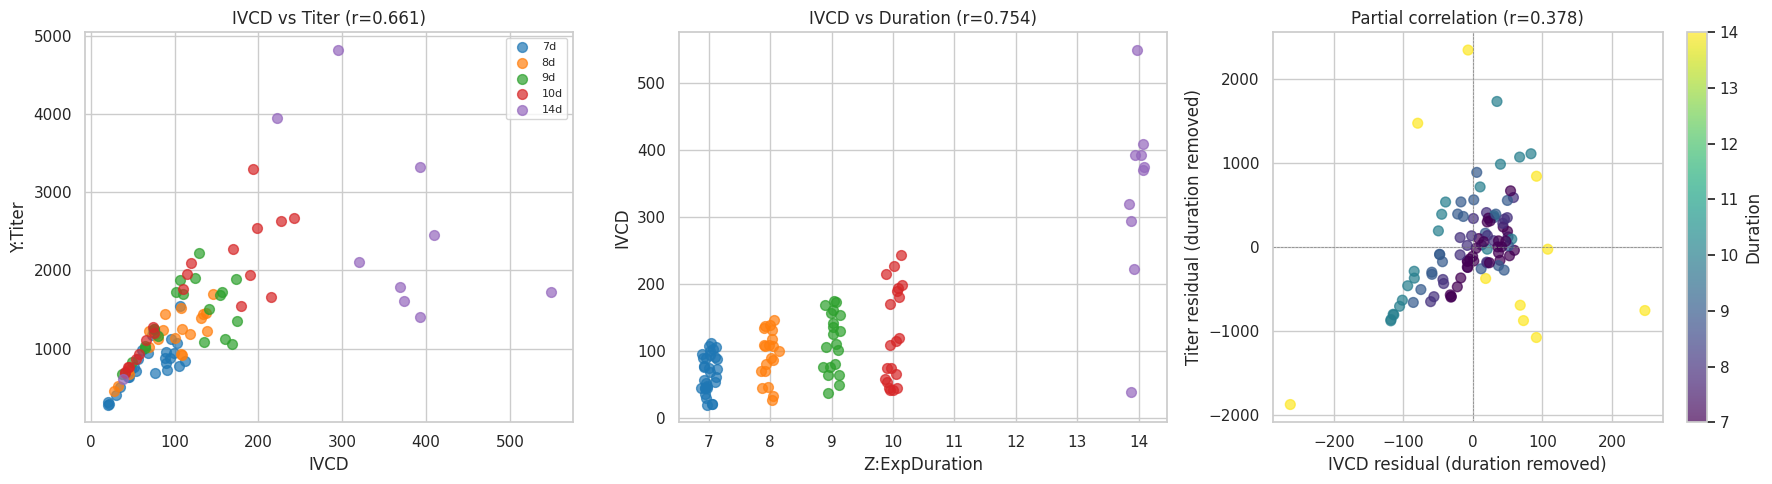

Raw IVCD-Titer r = 0.661  |  IVCD-Duration r = 0.754  |  Partial r = 0.378


In [7]:
# IVCD (Integrated Viable Cell Density) vs Titer
# Literature: iVCC is the strongest single predictor of titer (Clavaud 2013: R²=0.95)

ivcd_list = []
for exp_name in exp_info["Exp"]:
    edata = train_data[train_data["Exp"] == exp_name].sort_values("Time[day]")
    ivcd = np.trapezoid(edata["X:VCD"].values, edata["Time[day]"].values)
    ivcd_list.append({"Exp": exp_name, "IVCD": ivcd})

ivcd_df = pd.DataFrame(ivcd_list).merge(exp_info[["Exp", "Y:Titer", "Z:ExpDuration"]], on="Exp")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. IVCD vs Titer (raw)
r_raw = ivcd_df["IVCD"].corr(ivcd_df["Y:Titer"])
for dur, color in dur_colors.items():
    m = ivcd_df["Z:ExpDuration"] == dur
    axes[0].scatter(ivcd_df.loc[m, "IVCD"], ivcd_df.loc[m, "Y:Titer"],
                    color=color, alpha=0.7, s=50, label=f"{int(dur)}d")
axes[0].set(xlabel="IVCD", ylabel="Y:Titer", title=f"IVCD vs Titer (r={r_raw:.3f})")
axes[0].legend(fontsize=8)

# 2. IVCD vs Duration — the confound
r_dur = ivcd_df["IVCD"].corr(ivcd_df["Z:ExpDuration"])
for dur, color in dur_colors.items():
    m = ivcd_df["Z:ExpDuration"] == dur
    axes[1].scatter(ivcd_df.loc[m, "Z:ExpDuration"] + np.random.uniform(-0.15, 0.15, m.sum()),
                    ivcd_df.loc[m, "IVCD"], color=color, alpha=0.7, s=50)
axes[1].set(xlabel="Z:ExpDuration", ylabel="IVCD", title=f"IVCD vs Duration (r={r_dur:.3f})")

# 3. Partial correlation: residuals after removing duration from both
dur = ivcd_df["Z:ExpDuration"].values
ivcd_resid = ivcd_df["IVCD"] - np.polyval(np.polyfit(dur, ivcd_df["IVCD"], 1), dur)
titer_resid = ivcd_df["Y:Titer"] - np.polyval(np.polyfit(dur, ivcd_df["Y:Titer"], 1), dur)
r_partial = ivcd_resid.corr(titer_resid)
axes[2].scatter(ivcd_resid, titer_resid, c=ivcd_df["Z:ExpDuration"], cmap="viridis", alpha=0.7, s=50)
axes[2].axhline(0, color="gray", ls="--", lw=0.5)
axes[2].axvline(0, color="gray", ls="--", lw=0.5)
axes[2].set(xlabel="IVCD residual (duration removed)", ylabel="Titer residual (duration removed)",
            title=f"Partial correlation (r={r_partial:.3f})")
plt.colorbar(axes[2].collections[0], ax=axes[2], label="Duration")

plt.tight_layout()
plt.show()

print(f"Raw IVCD-Titer r = {r_raw:.3f}  |  IVCD-Duration r = {r_dur:.3f}  |  Partial r = {r_partial:.3f}")

**Is IVCD the dominant predictor, as Clavaud et al. (2013) reported (R²=0.95)?** Raw correlation is strong (r=0.661), but IVCD naturally grows with experiment duration (r=0.754) — longer cultures accumulate more cell-days. In our variable-duration dataset, this shared dependence inflates the apparent predictive power. Partial correlation controlling for duration: r=0.378. Clavaud’s R²=0.95 was on fixed-duration batches where this confound doesn’t exist. IVCD is a meaningful feature but not sufficient on its own here.

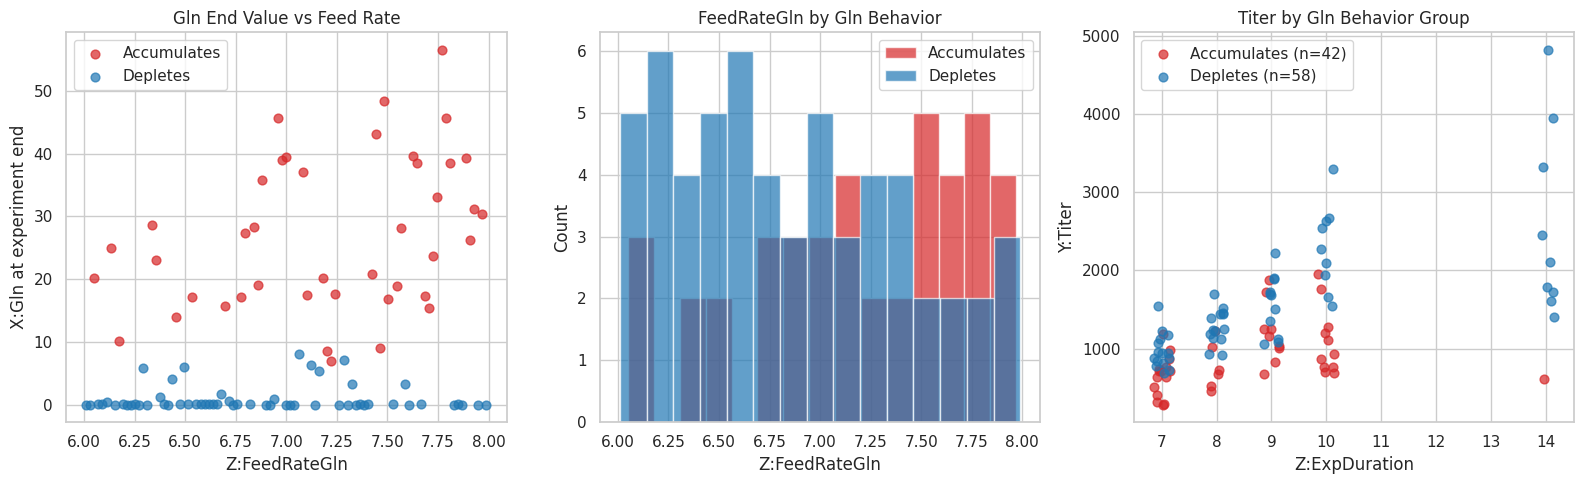

Gln accumulators: 42/100, Gln depleters: 58/100

Z:FeedRateGln by group:
                 count     mean       std
gln_accumulates                          
False             58.0  6.85371  0.557873
True              42.0  7.20202  0.547758

Titer by group:
                 count         mean         std
gln_accumulates                                
False             58.0  1614.562206  805.044929
True              42.0   900.145693  406.420223


In [8]:
# Investigate Gln bimodal split — what Z: params drive it?
# Observation from cell 4: some experiments deplete Gln to 0, others accumulate to 15-40

gln_behavior = []
for exp_name in exp_info["Exp"]:
    edata = train_data[train_data["Exp"] == exp_name].sort_values("Time[day]")
    gln_s, gln_e = edata["X:Gln"].iloc[0], edata["X:Gln"].iloc[-1]
    gln_behavior.append({
        "Exp": exp_name, "gln_end": gln_e, "gln_max": edata["X:Gln"].max(),
        "gln_accumulates": gln_e > gln_s * 1.5,
    })
gln_df = pd.DataFrame(gln_behavior).merge(z_table, on="Exp")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
groups = [(True, "Accumulates", "#d62728"), (False, "Depletes", "#1f77b4")]

# 1. Gln end value vs FeedRateGln
for acc, label, color in groups:
    m = gln_df["gln_accumulates"] == acc
    axes[0].scatter(gln_df.loc[m, "Z:FeedRateGln"], gln_df.loc[m, "gln_end"],
                    color=color, alpha=0.7, s=40, label=label)
axes[0].set(xlabel="Z:FeedRateGln", ylabel="X:Gln at experiment end", title="Gln End Value vs Feed Rate")
axes[0].legend()

# 2. FeedRateGln distribution by group
for acc, label, color in groups:
    axes[1].hist(gln_df.loc[gln_df["gln_accumulates"] == acc, "Z:FeedRateGln"],
                 bins=15, alpha=0.7, label=label, color=color)
axes[1].set(xlabel="Z:FeedRateGln", ylabel="Count", title="FeedRateGln by Gln Behavior")
axes[1].legend()

# 3. Titer by group (jittered by duration)
for acc, label, color in groups:
    m = gln_df["gln_accumulates"] == acc
    axes[2].scatter(gln_df.loc[m, "Z:ExpDuration"] + np.random.uniform(-0.15, 0.15, m.sum()),
                    gln_df.loc[m, "Y:Titer"], color=color, alpha=0.7, s=40, label=f"{label} (n={m.sum()})")
axes[2].set(xlabel="Z:ExpDuration", ylabel="Y:Titer", title="Titer by Gln Behavior Group")
axes[2].legend()

plt.tight_layout()
plt.show()

n_acc = gln_df["gln_accumulates"].sum()
print(f"Gln accumulators: {n_acc}/100, Gln depleters: {100 - n_acc}/100")
print(f"\nZ:FeedRateGln by group:")
print(gln_df.groupby("gln_accumulates")["Z:FeedRateGln"].describe()[["count", "mean", "std"]].to_string())
print(f"\nTiter by group:")
print(gln_df.groupby("gln_accumulates")["Y:Titer"].describe()[["count", "mean", "std"]].to_string())

**What drives the bimodal Gln split seen in the trajectory plot?** 42 experiments accumulate Gln, 58 deplete it. Feed rate (Z:FeedRateGln) is NOT the driver — both groups have similar distributions (mean 6.85 vs 7.20, overlapping). Accumulators produce lower titer (mean 900 vs 1615), but this is confounded with VCD: cells that don’t grow fast enough can’t consume the glutamine being fed. The root cause is investigated next — accumulation is a *consequence* of low VCD, not an independent predictor.

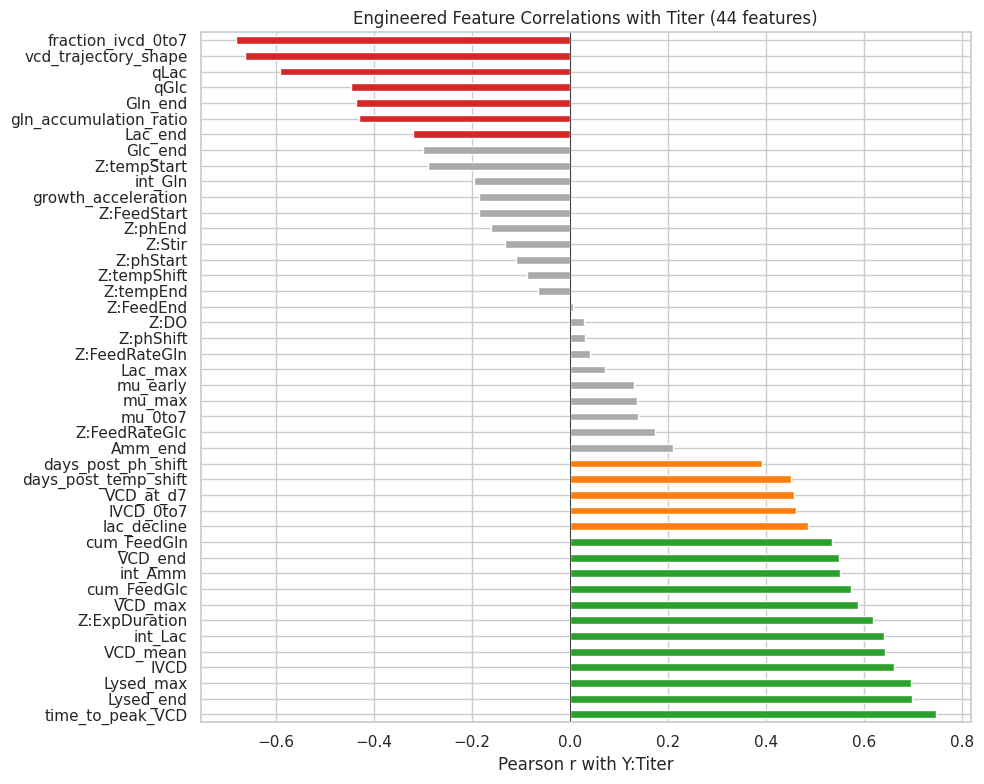

=== Top 10 feature correlations with Y:Titer ===
  time_to_peak_VCD           r = +0.746
  Lysed_end                  r = +0.698
  Lysed_max                  r = +0.696
  IVCD                       r = +0.661
  VCD_mean                   r = +0.642
  int_Lac                    r = +0.641
  Z:ExpDuration              r = +0.618
  VCD_max                    r = +0.587
  cum_FeedGlc                r = +0.572
  int_Amm                    r = +0.550

=== Bottom 5 ===
  Gln_end                    r = -0.438
  qGlc                       r = -0.448
  qLac                       r = -0.593
  vcd_trajectory_shape       r = -0.664
  fraction_ivcd_0to7         r = -0.682


In [9]:
# Feature correlation summary — rank engineered features by titer correlation
# Use the feature engineering module rather than reimplementing extraction here
import sys; sys.path.insert(0, "..")
from src.features import extract_features_from_dataframe

feat_df = extract_features_from_dataframe(train_data)
feat_df = feat_df.merge(exp_info[["Exp", "Y:Titer"]], on="Exp")

# Correlations with titer (exclude identifiers)
feat_cols = [c for c in feat_df.columns if c not in ["Exp", "Y:Titer"]]
corrs = feat_df[feat_cols + ["Y:Titer"]].corr()["Y:Titer"].drop("Y:Titer").sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ["#2ca02c" if v > 0.5 else "#ff7f0e" if v > 0.3 else "#d62728" if v < -0.3 else "#aaaaaa"
          for v in corrs.values]
corrs.plot.barh(ax=ax, color=colors)
ax.set_xlabel("Pearson r with Y:Titer")
ax.set_title("Engineered Feature Correlations with Titer (44 features)")
ax.axvline(0, color="black", lw=0.5)
plt.tight_layout()
plt.show()

print("=== Top 10 feature correlations with Y:Titer ===")
for feat, r in corrs.head(10).items():
    print(f"  {feat:25s}  r = {r:+.3f}")
print(f"\n=== Bottom 5 ===")
for feat, r in corrs.tail(5).items():
    print(f"  {feat:25s}  r = {r:+.3f}")

**How do all 44 engineered features rank by raw titer correlation?** Top features (time_to_peak_VCD r=0.75, Lysed_end r=0.70, IVCD r=0.66) look strong, but Z:ExpDuration sits at r=0.62 right among them — a warning sign. Many of these top correlations may be inflated by the shared duration dependence, as we saw with IVCD. The next cell controls for duration to reveal which features carry independent signal.

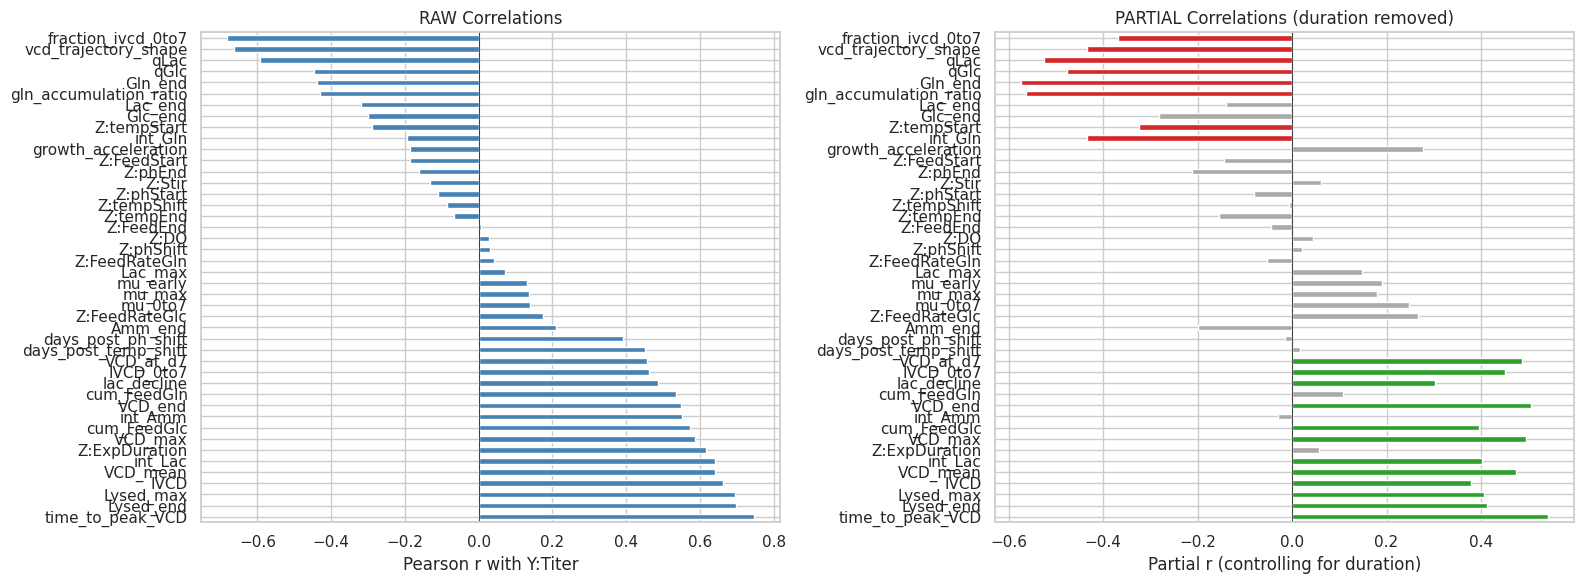

=== Raw vs Partial correlations ===
        Feature   raw_r partial_r r_w_dur
time_to_peak_VCD  +0.746    +0.541  +0.760 <-- duration proxy
      Lysed_end  +0.698    +0.412  +0.883 <-- duration proxy
      Lysed_max  +0.696    +0.407  +0.882 <-- duration proxy
           IVCD  +0.661    +0.378  +0.754 <-- duration proxy
       VCD_mean  +0.642    +0.473  +0.527
        int_Lac  +0.641    +0.402  +0.647
  Z:ExpDuration  +0.618    +0.057  +1.000 <-- duration proxy
        VCD_max  +0.587    +0.495  +0.362
    cum_FeedGlc  +0.572    +0.395  +0.488
        int_Amm  +0.550    -0.030  +0.907 <-- duration proxy
        VCD_end  +0.550    +0.506  +0.269
    cum_FeedGln  +0.535    +0.107  +0.780 <-- duration proxy
    lac_decline  +0.485    +0.302  +0.439
      IVCD_0to7  +0.461    +0.451  +0.182
      VCD_at_d7  +0.457    +0.487  +0.124
days_post_temp_shift  +0.451    +0.017  +0.715 <-- duration proxy
days_post_ph_shift  +0.393    -0.015  +0.650
        Amm_end  +0.210    -0.198  +0.551
  Z:F

In [10]:
# PARTIAL CORRELATIONS: controlling for Z:ExpDuration
# Reviewers flagged that most top features are duration proxies. Let's quantify.

def partial_corr(df, feat, target="Y:Titer", control="Z:ExpDuration"):
    mask = df[[feat, target, control]].dropna().index
    d = df.loc[mask]
    c_f = np.polyfit(d[control], d[feat], 1)
    c_t = np.polyfit(d[control], d[target], 1)
    return (d[feat] - np.polyval(c_f, d[control])).corr(d[target] - np.polyval(c_t, d[control]))

feat_cols_ordered = corrs.index.tolist()
partial_corrs = {f: partial_corr(feat_df, f) for f in feat_cols_ordered}
dur_corrs = {f: feat_df[f].corr(feat_df["Z:ExpDuration"]) for f in feat_cols_ordered}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

pd.Series({f: corrs[f] for f in feat_cols_ordered}).plot.barh(ax=axes[0], color="steelblue")
axes[0].set_xlabel("Pearson r with Y:Titer")
axes[0].set_title("RAW Correlations")
axes[0].axvline(0, color="black", lw=0.5)

pc_series = pd.Series(partial_corrs)
colors_p = ["#2ca02c" if v > 0.3 else "#d62728" if v < -0.3 else "#aaaaaa" for v in pc_series.values]
pc_series.plot.barh(ax=axes[1], color=colors_p)
axes[1].set_xlabel("Partial r (controlling for duration)")
axes[1].set_title("PARTIAL Correlations (duration removed)")
axes[1].axvline(0, color="black", lw=0.5)

plt.tight_layout()
plt.show()

print("=== Raw vs Partial correlations ===")
header = "Feature".rjust(15) + "raw_r".rjust(8) + "partial_r".rjust(10) + "r_w_dur".rjust(8)
print(header)
for f in feat_cols_ordered:
    r, p, d = corrs[f], partial_corrs[f], dur_corrs[f]
    flag = " <-- duration proxy" if abs(d) > 0.7 else ""
    line = f.rjust(15) + f"{r:+.3f}".rjust(8) + f"{p:+.3f}".rjust(10) + f"{d:+.3f}".rjust(8) + flag
    print(line)

**Which features carry independent signal after controlling for duration?** This is the pivotal analysis. Partial correlations reveal dramatic reordering: int_Amm drops from r=+0.55 to partial r=−0.03 (entirely a duration artifact), Amm_end reverses sign (+0.21 → −0.20), while int_Gln jumps from −0.20 to −0.43 (was suppressed by duration). VCD_end and VCD_max survive as the strongest independent predictors (partial r ~0.50). Features flagged as “duration proxy” (r_with_duration > 0.7) should be used cautiously or alongside duration-aware validation.

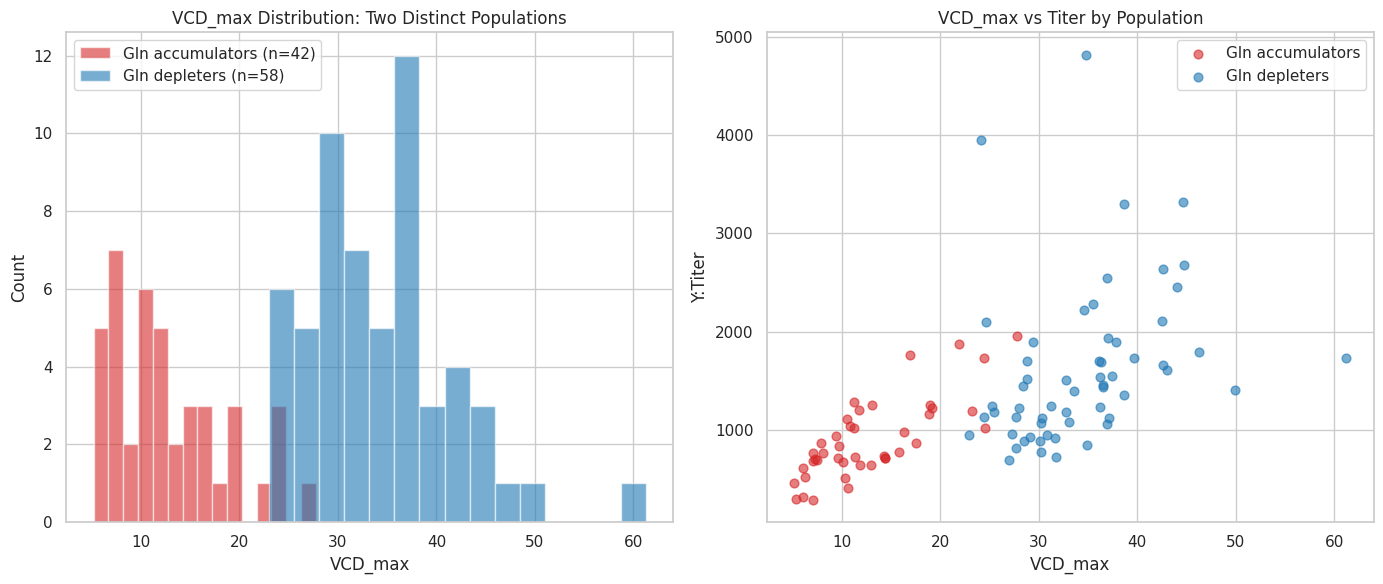

Accumulators: VCD_max 5.2-27.8 (mean 12.7)
Depleters:    VCD_max 23.0-61.2 (mean 34.4)

All experiments with VCD_max < 20 are accumulators: True


In [11]:
# CRITICAL FINDING: Gln accumulators = Low VCD — same population

vcd_gln = []
for exp_name in exp_info["Exp"]:
    edata = train_data[train_data["Exp"] == exp_name].sort_values("Time[day]")
    gln_s, gln_e = edata["X:Gln"].iloc[0], edata["X:Gln"].iloc[-1]
    vcd_gln.append({
        "Exp": exp_name, "VCD_max": edata["X:VCD"].max(),
        "gln_acc": gln_e > gln_s * 1.5, "gln_end": gln_e,
    })
vg = pd.DataFrame(vcd_gln).merge(exp_info[["Exp", "Y:Titer", "Z:ExpDuration"]], on="Exp")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for acc, label, color in [(True, "Gln accumulators", "#d62728"), (False, "Gln depleters", "#1f77b4")]:
    subset = vg[vg["gln_acc"] == acc]
    axes[0].hist(subset["VCD_max"], bins=15, alpha=0.6, label=label + " (n=" + str(len(subset)) + ")", color=color)
axes[0].set_xlabel("VCD_max")
axes[0].set_ylabel("Count")
axes[0].set_title("VCD_max Distribution: Two Distinct Populations")
axes[0].legend()

for acc, label, color in [(True, "Gln accumulators", "#d62728"), (False, "Gln depleters", "#1f77b4")]:
    subset = vg[vg["gln_acc"] == acc]
    axes[1].scatter(subset["VCD_max"], subset["Y:Titer"], c=color, alpha=0.6, s=40, label=label)
axes[1].set_xlabel("VCD_max")
axes[1].set_ylabel("Y:Titer")
axes[1].set_title("VCD_max vs Titer by Population")
axes[1].legend()

plt.tight_layout()
plt.show()

acc_vcd = vg[vg["gln_acc"]]["VCD_max"]
dep_vcd = vg[~vg["gln_acc"]]["VCD_max"]
print("Accumulators: VCD_max " + f"{acc_vcd.min():.1f}-{acc_vcd.max():.1f} (mean {acc_vcd.mean():.1f})")
print("Depleters:    VCD_max " + f"{dep_vcd.min():.1f}-{dep_vcd.max():.1f} (mean {dep_vcd.mean():.1f})")
print()
below20 = vg[vg["VCD_max"] < 20]
print("All experiments with VCD_max < 20 are accumulators: " + str(below20["gln_acc"].all()))

**Are Gln accumulation and low VCD the same population?** Yes — all 37 experiments with VCD_max < 20 are accumulators. The two groups separate cleanly on VCD_max. This confirms that Gln accumulation is a consequence of low cell growth (cells can’t consume the feed), not a separate biological signal. Implication for modeling: once VCD_max is in the feature set, Gln accumulator/depleter status is redundant.

## Key Takeaways for Modeling

1. **Duration is the dominant confound.** Most raw feature correlations are duration proxies. Partial correlations reveal the true independent predictors: VCD_end, VCD_max, int_Gln, int_Lac. Features like int_Amm (partial r≈0) are entirely spurious.
2. **IVCD is useful but not dominant.** Clavaud’s R²=0.95 doesn’t apply to variable-duration data. Partial r=0.378 after controlling for duration.
3. **Gln bimodal split = low VCD.** Not an independent phenomenon — redundant once VCD_max is included.
4. **Standard K-Fold will be misleading** — test is 100% 14d, training is 90% short experiments. We need duration-aware validation.
5. **All experiments share days 0-7.** A 7-day experiment IS the first 7 days of a 14-day experiment. Common-window features can compare experiments on equal footing regardless of duration. Explored in the modeling notebook.